# Notebook 1 — Cooper-Pair Box: Charge Dispersion

Reproduce the central plot of Koch et al. 2007 (PRA 76, 042319), Fig. 2:
the charge dispersion of the lowest few CPB eigenstates as a function of
the gate charge $n_g$, for several values of $E_J/E_C$.

**Hamiltonian:**
$$
H = 4 E_C (\hat n - n_g)^2 \;-\; E_J \cos\hat\delta
$$

In the charge basis $\{|n\rangle\}$, $\hat n = \sum_n n |n\rangle\langle n|$
and $\cos\hat\delta = \tfrac{1}{2}\sum_n \big(|n\rangle\langle n+1| + \mathrm{h.c.}\big)$.

**Goal:** show that as $E_J/E_C$ increases, the bands flatten exponentially in $\sqrt{8 E_J/E_C}$ — this is the transmon design principle.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Inline plots in JupyterLab
%matplotlib inline

# Slightly nicer default plot style
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Setup OK")

Setup OK


In [2]:
def cpb_hamiltonian(EJ_over_EC, ng, N=30):
    """
    Build the Cooper-Pair Box Hamiltonian in the charge basis.

    H = 4 E_C (n - ng)^2  -  E_J cos(delta)

    Energy unit: E_C = 1.  All energies are returned in units of E_C.

    Parameters
    ----------
    EJ_over_EC : float
        Josephson energy in units of charging energy.
    ng : float
        Gate (offset) charge, in units of 2e.
    N : int
        Charge-basis truncation: states |-N>, ..., |+N>.

    Returns
    -------
    H : (2N+1, 2N+1) ndarray
        Hermitian Hamiltonian matrix.
    """
    n = np.arange(-N, N + 1)            # charge quantum numbers
    diag = 4.0 * (n - ng) ** 2          # diagonal: 4 E_C (n - ng)^2 with E_C = 1
    off = -0.5 * EJ_over_EC             # off-diagonal: -E_J/2 from cos(delta)
    H = np.diag(diag) + np.diag(np.full(2 * N, off), k=1) \
                       + np.diag(np.full(2 * N, off), k=-1)
    return H


# Quick sanity check: at EJ = 0, eigenvalues should equal the parabolas 4 (n - ng)^2.
H = cpb_hamiltonian(EJ_over_EC=0.0, ng=0.0, N=10)
evals = np.sort(np.linalg.eigvalsh(H))
expected = np.sort(4.0 * np.arange(-10, 11) ** 2)
print("EJ=0 sanity check (should all be ~0):",
      np.max(np.abs(evals - expected)))

EJ=0 sanity check (should all be ~0): 0.0


In [3]:
# Parameters of the sweep
EJ_over_EC_values = [1.0, 5.0, 10.0, 50.0]   # 4 panels of Koch Fig. 2
ng_grid = np.linspace(-2.0, 2.0, 401)        # gate-charge axis
N_levels = 4                                  # plot the lowest 4 bands
N_charge = 30                                 # charge-basis truncation

# Storage: results[EJ/EC] = array of shape (len(ng_grid), N_levels)
results = {}
for ratio in EJ_over_EC_values:
    bands = np.empty((len(ng_grid), N_levels))
    for i, ng in enumerate(ng_grid):
        H = cpb_hamiltonian(ratio, ng, N=N_charge)
        # eigvalsh returns eigenvalues of a Hermitian matrix in ascending order
        evals = np.linalg.eigvalsh(H)
        bands[i, :] = evals[:N_levels]
    # Reference each curve to the bottom of the m=0 band so the plot is anchored
    bands -= bands[:, 0].min()
    results[ratio] = bands

print("Diagonalised", len(EJ_over_EC_values), "values of EJ/EC across",
      len(ng_grid), "ng points")

Diagonalised 4 values of EJ/EC across 401 ng points


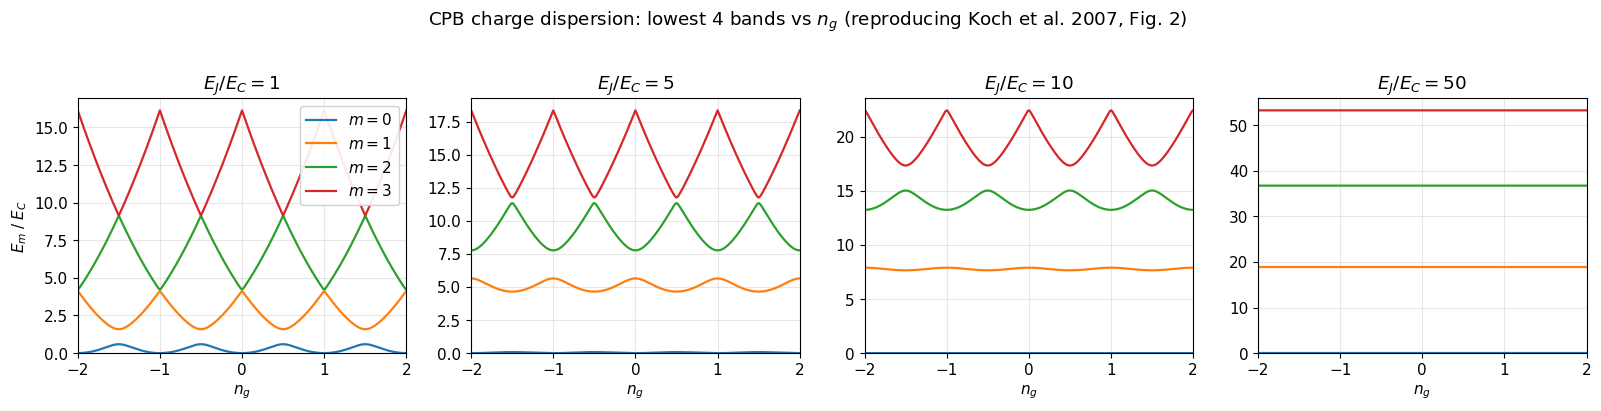

Figure saved to figures/01_cpb_charge_dispersion.png


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for ax, ratio in zip(axes, EJ_over_EC_values):
    bands = results[ratio]
    for m in range(N_levels):
        ax.plot(ng_grid, bands[:, m], lw=1.6, label=f"$m={m}$")
    ax.set_title(rf"$E_J / E_C = {ratio:g}$")
    ax.set_xlabel(r"$n_g$")
    ax.set_xlim(-2, 2)
    # Auto-scale y to roughly the lowest few bands of this panel
    ax.set_ylim(0, bands[:, N_levels - 1].max() * 1.05)

axes[0].set_ylabel(r"$E_m \;/\; E_C$")
axes[0].legend(loc="upper right", framealpha=0.9)

fig.suptitle(
    r"CPB charge dispersion: lowest %d bands vs $n_g$ "
    r"(reproducing Koch et al. 2007, Fig. 2)" % N_levels,
    y=1.02,
)
fig.tight_layout()

# Save the figure to ../figures/ for the README to embed later
import os
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/01_cpb_charge_dispersion.png",
            dpi=200, bbox_inches="tight")

plt.show()
print("Figure saved to figures/01_cpb_charge_dispersion.png")

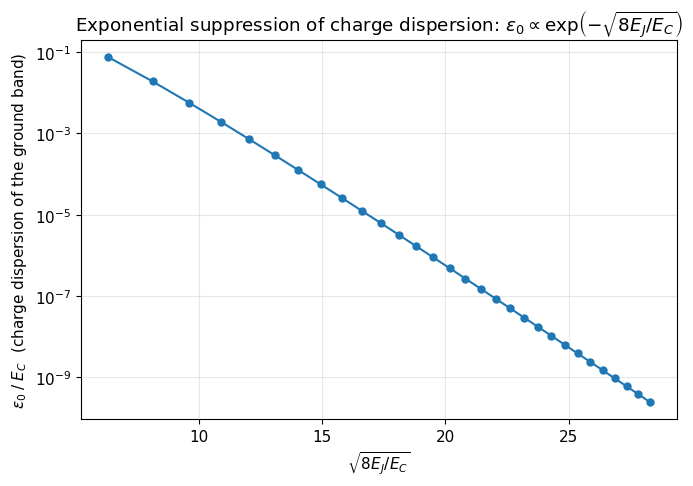

Figure saved to figures/01_cpb_dispersion_scaling.png


In [5]:
# Sweep a fine grid of EJ/EC and measure the dispersion of the m=0 band
ratio_grid = np.linspace(5, 100, 30)
dispersion = np.empty_like(ratio_grid)

for k, ratio in enumerate(ratio_grid):
    H_at_ng_0   = cpb_hamiltonian(ratio, ng=0.0,  N=N_charge)
    H_at_ng_half = cpb_hamiltonian(ratio, ng=0.5, N=N_charge)
    e0_at_0    = np.linalg.eigvalsh(H_at_ng_0)[0]
    e0_at_half = np.linalg.eigvalsh(H_at_ng_half)[0]
    dispersion[k] = abs(e0_at_half - e0_at_0)

# Plot log(dispersion) vs sqrt(8 EJ/EC). Theory predicts a straight line.
fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogy(np.sqrt(8 * ratio_grid), dispersion, "o-", lw=1.5, ms=5)
ax.set_xlabel(r"$\sqrt{8 E_J / E_C}$")
ax.set_ylabel(r"$\epsilon_0 \;/\; E_C$  (charge dispersion of the ground band)")
ax.set_title(
    r"Exponential suppression of charge dispersion: "
    r"$\epsilon_0 \propto \exp\!\left(-\sqrt{8 E_J/E_C}\right)$"
)

fig.tight_layout()
fig.savefig("../figures/01_cpb_dispersion_scaling.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Figure saved to figures/01_cpb_dispersion_scaling.png")